In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def in_phase_lorentz(A, f0, FWHM, f):
    # In phase Lorentzian with amplitude A centered at f0
    return (A / 4) * (1 / (((f - f0) / FWHM) ** 2 + 1 / 4))
def out_phase_lorentz(A, f0, FWHM, f):
    # Out of phase Lorentzian with amplitude A centered at f0
    return (A / (2 * FWHM)) * (f - f0) / (((f - f0) / FWHM) **2 + 1 / 4)
def complex_lorentz(A, f0, FWHM, f, phase):
    # Arbitrary phase Lorentzian with amplitude A centered at f0
    return np.cos(phase) * in_phase_lorentz(A, f0, FWHM, f) + np.sin(phase) * out_phase_lorentz(A, f0, FWHM, f)

In [278]:
def generate_lorentz(f):
    # Returns displacement and parameters for one random Lorentzian
    f_distance = max(f) - min(f)
    f0 = f_distance * np.random.random() + min(f)
    phase = 2 * np.pi * np.random.random()
    A = 50 * np.random.random()
    FWHM = f_distance * np.random.random() / 50
    params = np.array([[A, f0, FWHM, phase]])
    return complex_lorentz(A, f0, FWHM, f, phase), params
def generate_multi_lorentz(f, n):
    # Returns displacement and parameters for n random Lorentzians
    displacement = 0
    params = np.empty((0,4))
    for i in range(0, n):
        disp_addition, params_addition = generate_lorentz(f)
        displacement += disp_addition
        params = np.append(params, params_addition, axis=0)
    params = params[params[:, 1].argsort()]
    return displacement, params
def generate_background(f):
    # Returns one really big background Lorentzian and its paramteters
    f_distance = 100 * (max(f) - min(f))
    f0 = f_distance * np.random.random() + (100 * min(f))
    phase = 2 * np.pi * np.random.random()
    A = 5000 * np.random.random()
    FWHM = f_distance * np.random.random()
    params = np.array([[A, f0, FWHM, phase]])
    return complex_lorentz(A, f0, FWHM, f, phase), params
def generate_noise(f):
    # Returns slight background noise
    return np.random.normal(0, 1, f.shape)

In [731]:
def generate_data(include_noise=True):
    # Returns randomly generated data set and all its defining parameters
    num_lorentz = np.random.randint(16)
    f1, f2 = np.random.random() * 4000 - 2000, np.random.random() * 4000 - 2000
    f_min, f_max = min(f1, f2), max(f1, f2)
    f = np.linspace(f_min, f_max, int(2 * (f_max - f_min)))
    noise = generate_noise(f)
    if not include_noise:
        noise *= 0
    background, background_params = generate_background(f)
    lorentz, lorentz_params = generate_multi_lorentz(f, num_lorentz)
    displacement = noise + background + lorentz
    return background_params, lorentz_params, f, displacement

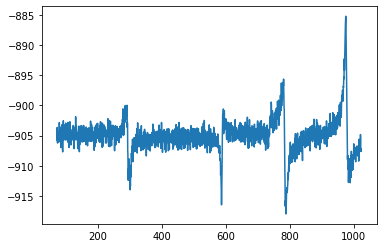

In [797]:
background_params, lorentz_params, f, displacement = generate_data()
plt.plot(f, displacement)
plt.show()

In [804]:
arr = np.array([1, 2, 3])
arr2 = np.array([4, 5 ,6])

In [807]:
np.transpose(np.vstack([arr, arr2]))

array([[1, 4],
       [2, 5],
       [3, 6]])